In [ ]:
import pandas as pd

In [7]:
import numpy as np

In [8]:
import os

In [5]:
import pandas as pd  # <--- You must import pandas first

# Option A: If the file is in the same folder as your script
file_path = "BMW sales data (2010-2024) (1).csv"

# Option B: If you need a full path, see Section 2 below
# file_path = r"C:\Users\YourName\Downloads\BMW sales data (2010-2024) (1).csv"

try:
    df = pd.read_csv(file_path, low_memory=False)
    print("Success! Dataset loaded.")
    print("Initial shape:", df.shape)
    print(df.head()) # Show the first 5 rows
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please check the file name and path.")

Success! Dataset loaded.
Initial shape: (50000, 11)
      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0      151748      98740          8300                 High  
1      121671      79219          3428                  Low  
2       10991     113265          6994                  Low  
3       27255      60971          4047                  Low  
4      122131      49898          3080                  Low  


In [10]:
# 2.REMOVE DUPLICATES
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Removed {before - after} duplicates")

Removed 0 duplicates


In [23]:
# 3. DATA TYPE CORRECTION
# -------------------------------
numeric_columns = [
    "Year", "Engine_Size_L", "Mileage_KM",
    "Price_USD", "Sales_Volume"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Year"] = df["Year"].astype("Int64")   # better nullable integer


In [13]:
# 4. MISSING VALUE TREATMENT
# -------------------------------
missing_before = df.isna().sum()
print("\nMissing values before filling:\n", missing_before)


Missing values before filling:
 Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64


In [14]:
# fill numeric missing using median
for col in numeric_columns:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [16]:

# fill categorical missing using mode
categorical_columns = [
    "Model", "Region", "Color",
    "Fuel_Type", "Transmission", "Sales_Classification"
]

for col in categorical_columns:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

missing_after = df.isna().sum()
print("\nMissing values after filling:\n", missing_after)


Missing values after filling:
 Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64


In [17]:
# 5. OUTLIER DETECTION (IQR) + WINSORIZATION
# -------------------------------
def winsorize_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(series, lower, upper)

for col in numeric_columns:
    df[col] = winsorize_iqr(df[col])

print("\nOutlier treatment complete.")


Outlier treatment complete.


In [18]:
# 6. DATA TRANSFORMATION
# -------------------------------

# log transform skewed vars
df["log_Price_USD"] = np.log1p(df["Price_USD"])
df["log_Mileage_KM"] = np.log1p(df["Mileage_KM"])

# vehicle age based on Year
df["Vehicle_Age"] = 2024 - df["Year"]
df["Vehicle_Age"] = df["Vehicle_Age"].clip(lower=0, upper=50)

print("\nTransformations added: log_Price_USD, log_Mileage_KM, Vehicle_Age")


Transformations added: log_Price_USD, log_Mileage_KM, Vehicle_Age


In [19]:
# 7. VALIDATION
# -------------------------------
issues = []

# Invalid years (must be between 2010–2024)
bad_years = df[(df["Year"] < 2010) | (df["Year"] > 2024)]
if len(bad_years) > 0:
    issues.append(f"Invalid years: {len(bad_years)} rows")

# Price cannot be ≤ 0
if (df["Price_USD"] <= 0).sum() > 0:
    issues.append("Some prices <= 0")

# Mileage cannot be negative
if (df["Mileage_KM"] < 0).sum() > 0:
    issues.append("Negative mileage detected")

print("\nValidation issues:", issues if issues else "No issues detected.")



Validation issues: No issues detected.


In [22]:
# 8 — SAVE CLEANED DATASET (100% FIXED VERSION)
# ============================================================

import os

# Choose a safe filename (no spaces)
output_file = "BMW_cleaned_dataset.csv"

# Save to current working directory
output_path = os.path.join(os.getcwd(), output_file)

df.to_csv(output_path, index=False, encoding="utf-8")

print("\n=====================================")
print("CLEANING COMPLETE")
print("Saved cleaned dataset to:", output_path)
print("Final shape:", df.shape)
print("=====================================")


CLEANING COMPLETE
Saved cleaned dataset to: C:\Users\Administrateur\Desktop\JUPYTER\BMW_cleaned_dataset.csv
Final shape: (50000, 14)


In [24]:
print("Shape:", df.shape)


Shape: (50000, 14)


In [25]:
print("\nColumns:")
print(df.columns.tolist())



Columns:
['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume', 'Sales_Classification', 'log_Price_USD', 'log_Mileage_KM', 'Vehicle_Age']


In [32]:
# Display the first 5 rows
df.tail()


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,log_Price_USD,log_Mileage_KM,Vehicle_Age
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,10.667396,11.925240,10
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,10.793742,11.900885,1
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,10.739154,12.072198,14
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,10.977927,8.125631,4
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low,11.257943,12.049442,4


In [33]:
# Show full data types
print("\nData Types:")
print(df.dtypes)



Data Types:
Model                    object
Year                      Int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification     object
log_Price_USD           float64
log_Mileage_KM          float64
Vehicle_Age               Int64
dtype: object


In [34]:
# Missing value check
print("\nMissing values per column:")
print(df.isna().sum())



Missing values per column:
Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
log_Price_USD           0
log_Mileage_KM          0
Vehicle_Age             0
dtype: int64


In [35]:
# Basic statistical summary
print("\nStatistical Summary:")
print(df.describe())



Statistical Summary:
            Year  Engine_Size_L     Mileage_KM      Price_USD  Sales_Volume  \
count    50000.0   50000.000000   50000.000000   50000.000000  50000.000000   
mean   2017.0157       3.247180  100307.203140   75034.600900   5067.514680   
std     4.324459       1.009078   57941.509344   25998.248882   2856.767125   
min       2010.0       1.500000       3.000000   30000.000000    100.000000   
25%       2013.0       2.400000   50178.000000   52434.750000   2588.000000   
50%       2017.0       3.200000  100388.500000   75011.500000   5087.000000   
75%       2021.0       4.100000  150630.250000   97628.250000   7537.250000   
max       2024.0       5.000000  199996.000000  119998.000000   9999.000000   

       log_Price_USD  log_Mileage_KM  Vehicle_Age  
count   50000.000000    50000.000000      50000.0  
mean       11.157792       11.207500       6.9843  
std         0.382002        1.002797     4.324459  
min        10.308986        1.386294          0.0  
25%   

In [36]:
# Unique values in categorical columns
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())



Column: Model
['5 Series' 'i8' 'X3' '7 Series' 'M5' '3 Series' 'X1' 'M3' 'X5' 'i3' 'X6']

Column: Region
['Asia' 'North America' 'Middle East' 'South America' 'Europe' 'Africa']

Column: Color
['Red' 'Blue' 'Black' 'Silver' 'White' 'Grey']

Column: Fuel_Type
['Petrol' 'Hybrid' 'Diesel' 'Electric']

Column: Transmission
['Manual' 'Automatic']

Column: Sales_Classification
['High' 'Low']


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Engine_Size_L'}>,
        <Axes: title={'center': 'Mileage_KM'}>],
       [<Axes: title={'center': 'Price_USD'}>,
        <Axes: title={'center': 'Sales_Volume'}>,
        <Axes: title={'center': 'log_Price_USD'}>],
       [<Axes: title={'center': 'log_Mileage_KM'}>,
        <Axes: title={'center': 'Vehicle_Age'}>, <Axes: >]], dtype=object)

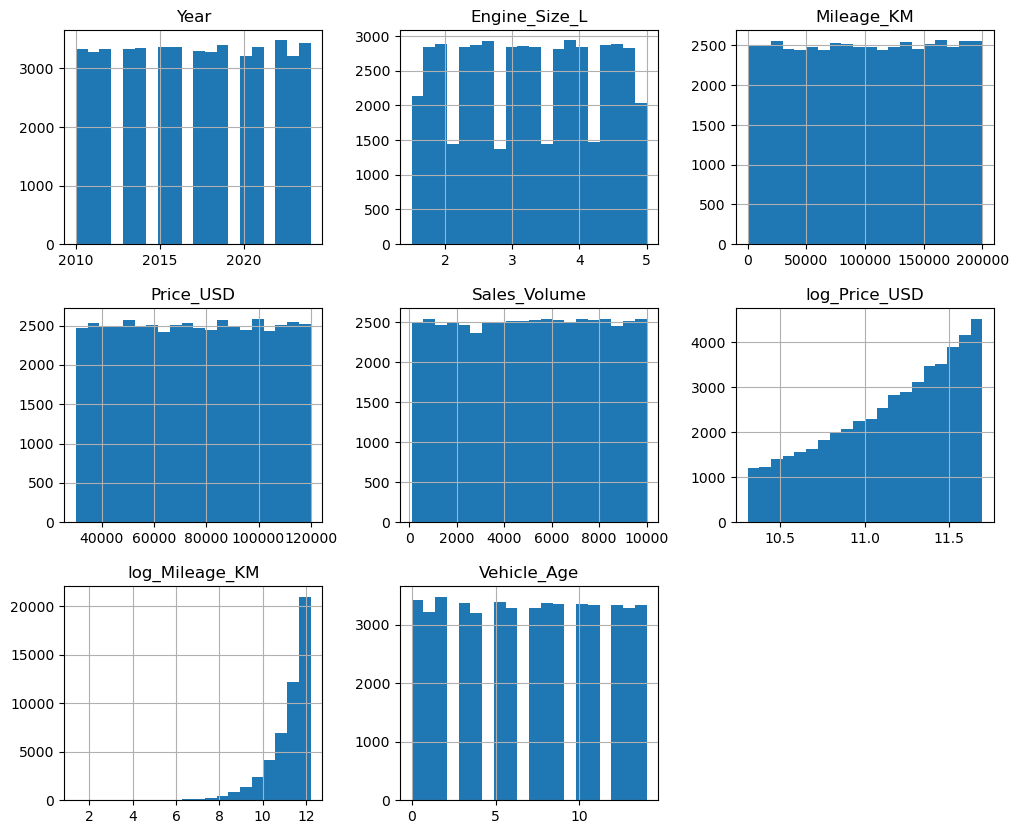

In [37]:
# Validate numeric columns visually
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(bins=20, figsize=(12,10))


In [38]:
# BMW DATASET EXPLORATORY DATA ANALYSIS (EDA) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [39]:
# Load the cleaned dataset
# --------------------
file_path = "BMW_cleaned_dataset.csv"
df = pd.read_csv(file_path)
print("Dataset loaded, shape:", df.shape)

Dataset loaded, shape: (50000, 14)


In [40]:
# General Overview
# --------------------
print("\n=== Columns and Data Types ===")
print(df.dtypes)

print("\n=== First 5 Rows ===")
display(df.head())

print("\n=== Last 5 Rows ===")
display(df.tail())

print("\n=== Missing Values ===")
print(df.isna().sum())



=== Columns and Data Types ===
Model                    object
Year                      int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification     object
log_Price_USD           float64
log_Mileage_KM          float64
Vehicle_Age               int64
dtype: object

=== First 5 Rows ===


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,log_Price_USD,log_Mileage_KM,Vehicle_Age
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,11.500256,11.929983,8
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,11.279984,11.709084,11
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,11.637494,9.304923,2
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,11.018170,10.213029,0
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,10.817756,11.712858,4



=== Last 5 Rows ===


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,log_Price_USD,log_Mileage_KM,Vehicle_Age
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,10.667396,11.925240,10
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,10.793742,11.900885,1
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,10.739154,12.072198,14
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,10.977927,8.125631,4
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low,11.257943,12.049442,4



=== Missing Values ===
Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
log_Price_USD           0
log_Mileage_KM          0
Vehicle_Age             0
dtype: int64


In [41]:
# Numeric Columns Summary
# --------------------
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("\nNumeric Columns:", numeric_cols)

print("\n=== Numeric Summary ===")
display(df[numeric_cols].describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]).transpose())


Numeric Columns: ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume', 'log_Price_USD', 'log_Mileage_KM', 'Vehicle_Age']

=== Numeric Summary ===


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
Year,50000.0,2017.015700,4.324459,2010.000000,2010.000000,2010.000000,2011.000000,2013.000000,2017.000000,2021.000000,2023.000000,2024.000000,2024.000000,2024.000000
Engine_Size_L,50000.0,3.247180,1.009078,1.500000,1.500000,1.700000,1.900000,2.400000,3.200000,4.100000,4.600000,4.800000,5.000000,5.000000
Mileage_KM,50000.0,100307.203140,57941.509344,3.000000,1947.920000,10013.700000,19972.800000,50178.000000,100388.500000,150630.250000,180525.100000,190219.800000,198047.010000,199996.000000
Price_USD,50000.0,75034.600900,25998.248882,30000.000000,30840.990000,34574.000000,39008.800000,52434.750000,75011.500000,97628.250000,111103.000000,115530.050000,119134.000000,119998.000000
Sales_Volume,50000.0,5067.514680,2856.767125,100.000000,204.000000,597.000000,1086.000000,2588.000000,5087.000000,7537.250000,9018.100000,9510.000000,9897.000000,9999.000000
log_Price_USD,50000.0,11.157792,0.382002,10.308986,10.336632,10.450886,10.571568,10.867344,11.225410,11.488932,11.618222,11.657295,11.688013,11.695239
log_Mileage_KM,50000.0,11.207500,1.002797,1.386294,7.575031,9.211809,9.902177,10.823352,11.516813,11.922590,12.103631,12.155941,12.196265,12.206058
Vehicle_Age,50000.0,6.984300,4.324459,0.000000,0.000000,0.000000,1.000000,3.000000,7.000000,11.000000,13.000000,14.000000,14.000000,14.000000


In [42]:
# Categorical Columns Summary
# --------------------
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("\nCategorical Columns:", categorical_cols)

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts().head(20))


Categorical Columns: ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']

Column: Model
Unique values: 11
Model
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413
Name: count, dtype: int64

Column: Region
Unique values: 6
Region
Asia             8454
Middle East      8373
North America    8335
Europe           8334
Africa           8253
South America    8251
Name: count, dtype: int64

Column: Color
Unique values: 6
Color
Red       8463
Silver    8350
Grey      8348
White     8304
Black     8273
Blue      8262
Name: count, dtype: int64

Column: Fuel_Type
Unique values: 4
Fuel_Type
Hybrid      12716
Petrol      12550
Electric    12471
Diesel      12263
Name: count, dtype: int64

Column: Transmission
Unique values: 2
Transmission
Manual       25154
Automatic    24846
Name: count, dtype: int64

Column: Sales_Classification
Un

ValueError: num must be an integer with 1 <= num <= 6, not 7

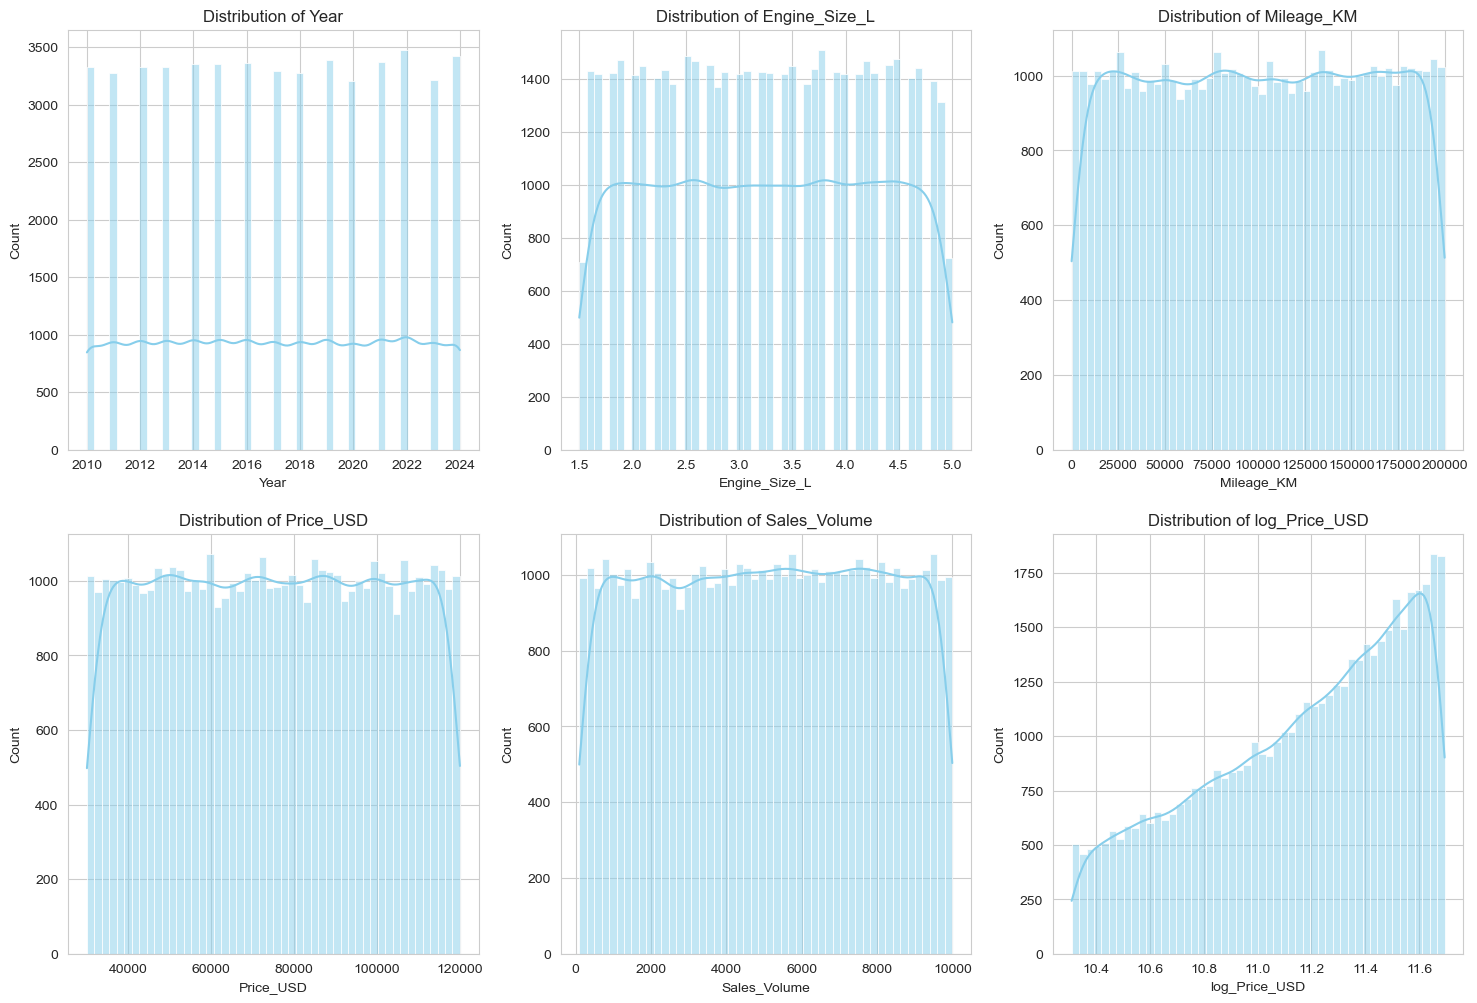

In [43]:
# Numeric Distribution Plots
# --------------------
sns.set_style("whitegrid")
plt.figure(figsize=(18,12))

for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], kde=True, bins=50, color='skyblue')
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

ValueError: num must be an integer with 1 <= num <= 6, not 7

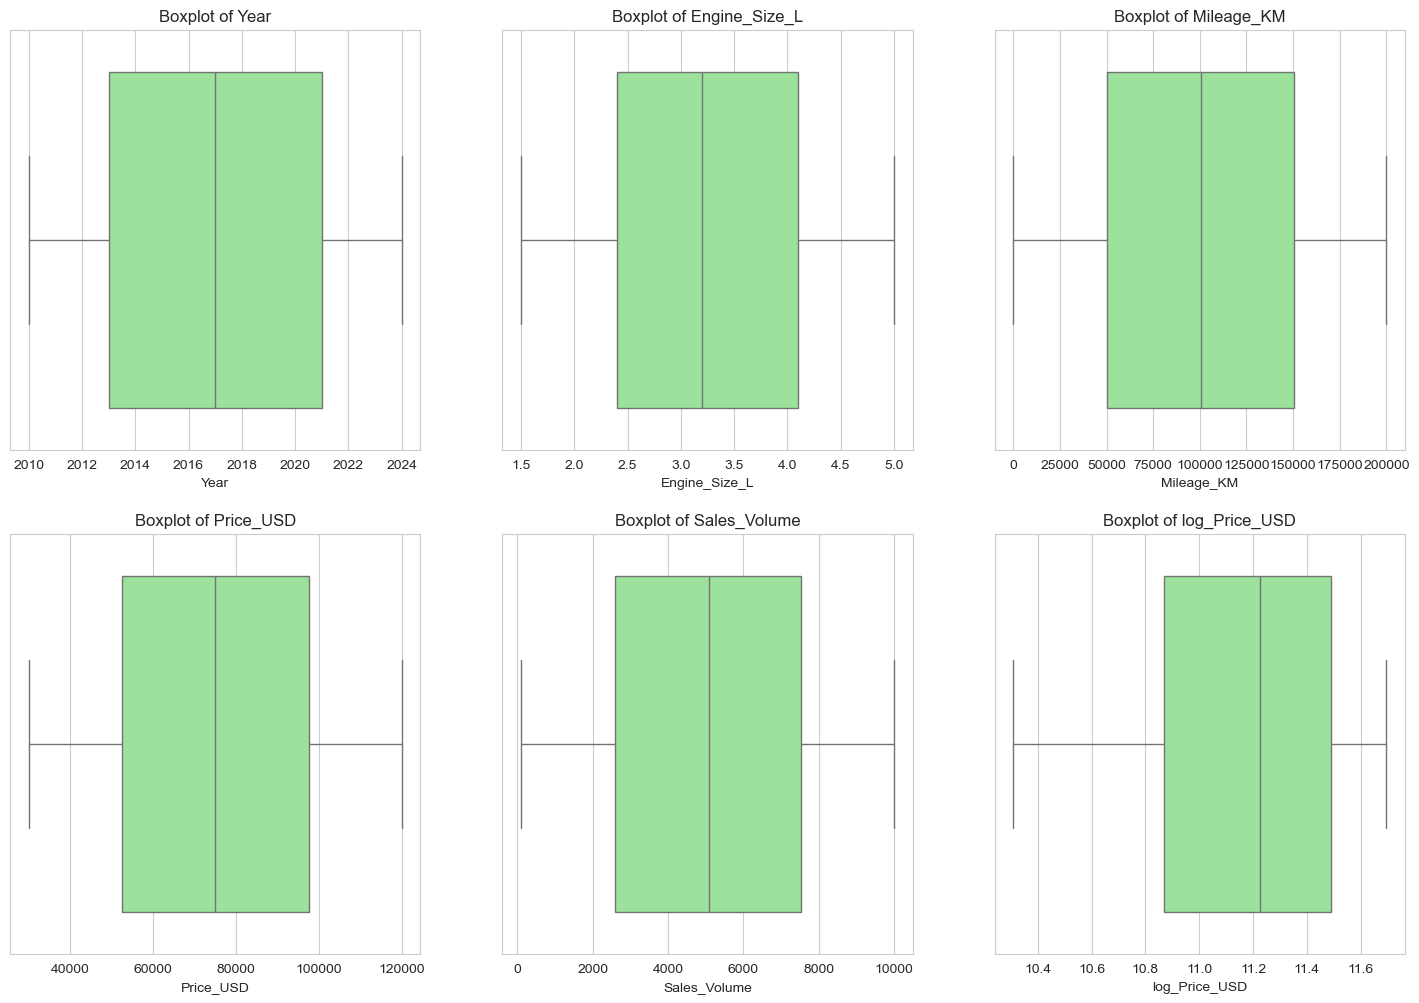

In [44]:
# Boxplots for Outlier Detection
# --------------------
plt.figure(figsize=(18,12))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

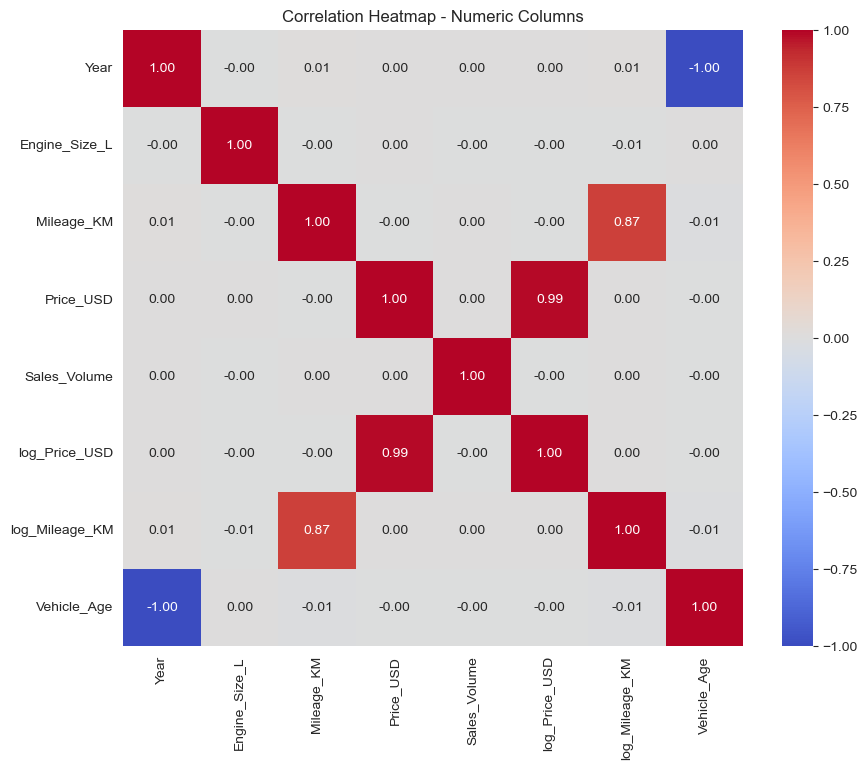

In [45]:
# Correlation Heatmap
# --------------------
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Numeric Columns")
plt.show()

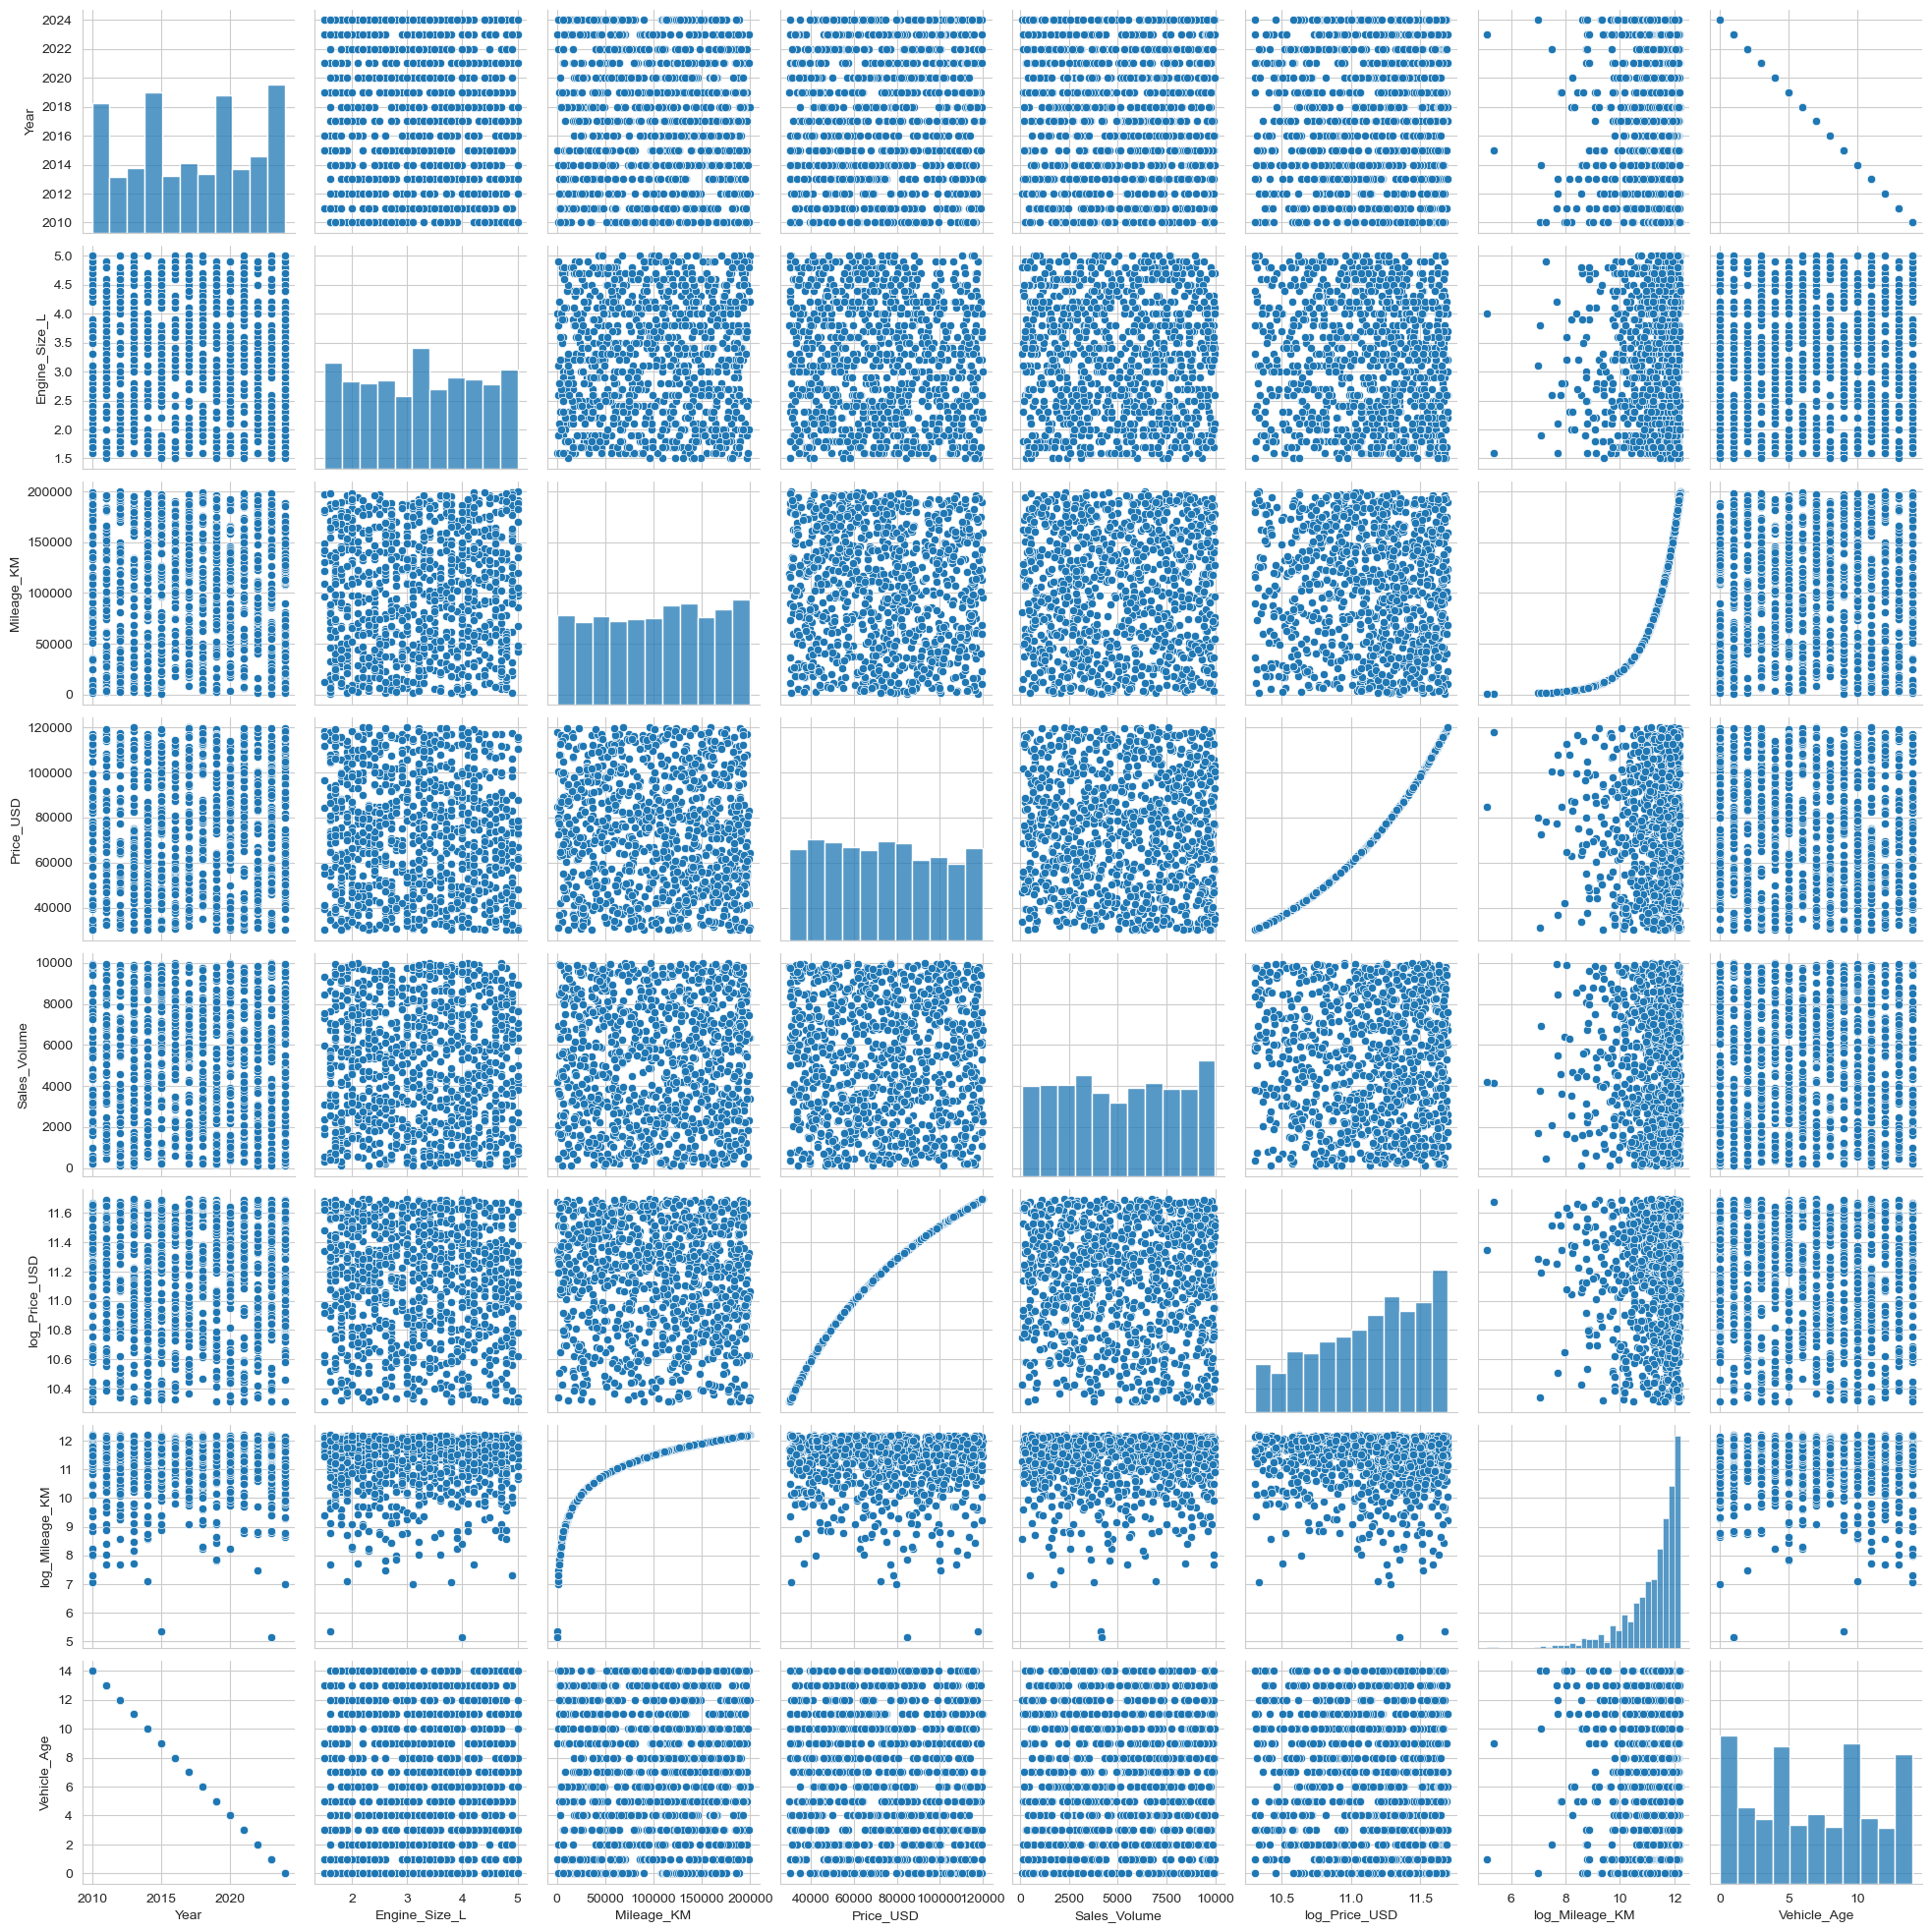

In [47]:
# Pairplots (optional for smaller samples)
# --------------------
# For large datasets, use a sample for pairplots
sample_df = df.sample(1000, random_state=42)
sns.pairplot(sample_df[numeric_cols])
plt.show()

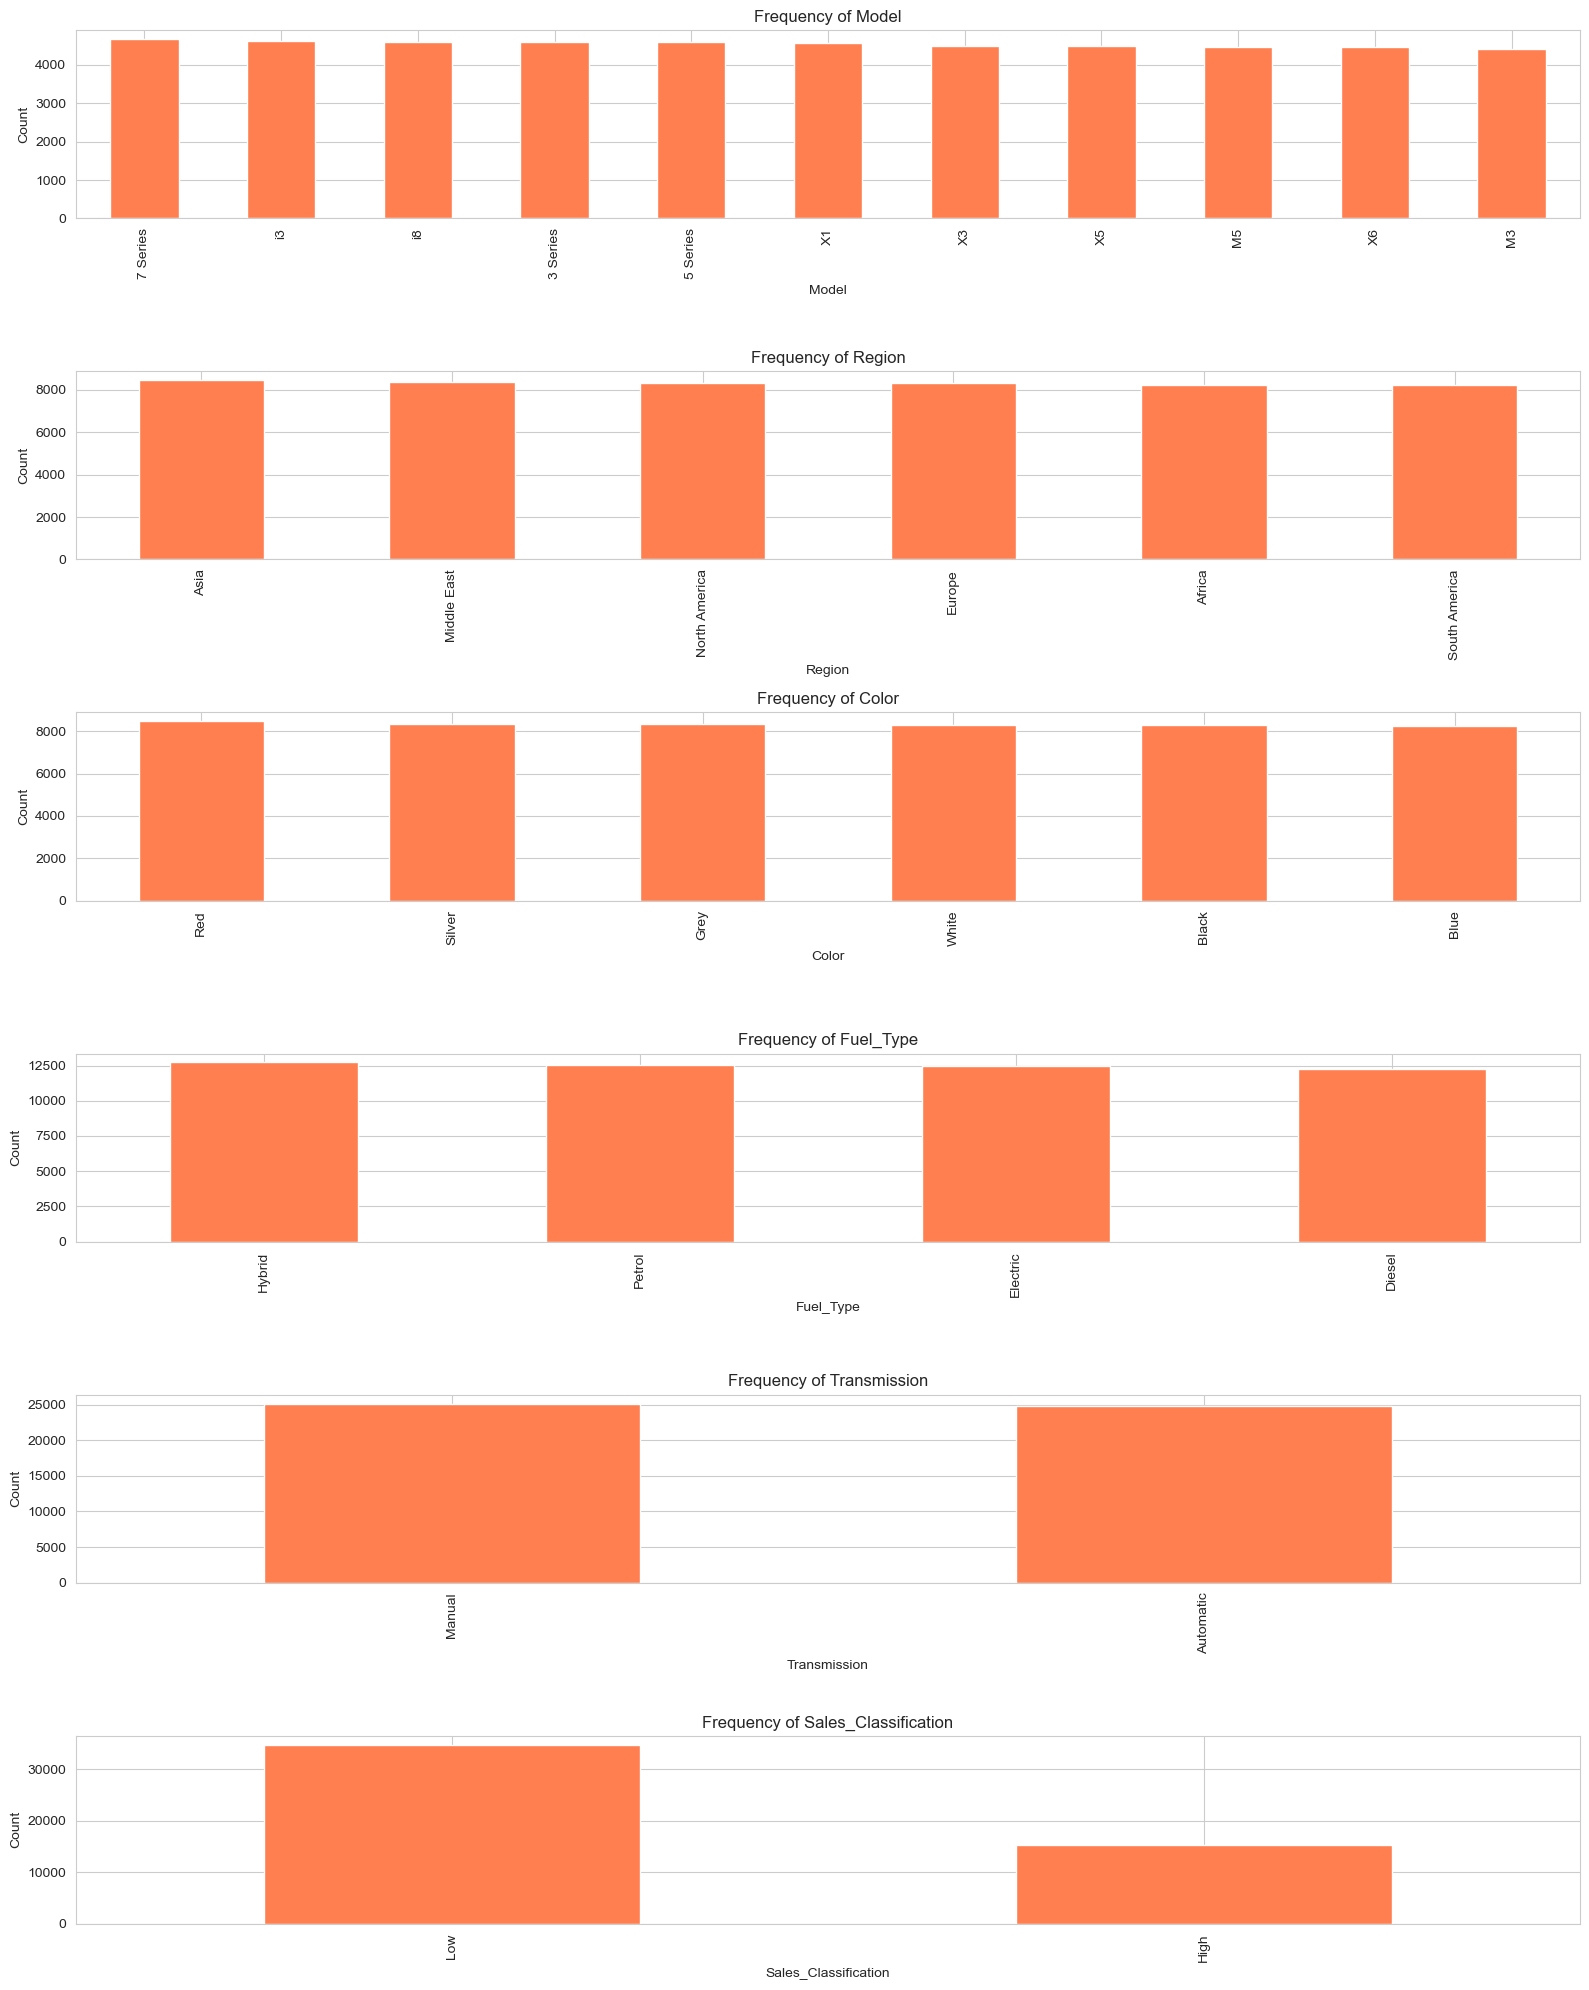

In [49]:
# Categorical Column Visualization
# --------------------
plt.figure(figsize=(16,20))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols),1,i+1)
    df[col].value_counts().plot(kind='bar', color='coral')
    plt.title(f"Frequency of {col}")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [52]:
# Engineered Features Insight (Vehicle Age & Mileage per Year)
# --------------------
if "Vehicle_Age" in df.columns and "Mileage_Per_Year" in df.columns:
    plt.figure(figsize=(12,5))
    sns.histplot(df["Vehicle_Age"], bins=25, color='skyblue', kde=True)
    plt.title("Distribution of Vehicle Age")
    plt.show()

    plt.figure(figsize=(12,5))
    sns.histplot(df["Mileage_Per_Year"], bins=50, color='salmon', kde=True)
    plt.title("Distribution of Mileage Per Year")
    plt.show()


In [60]:
# Save EDA Summary Tables
# --------------------
report_dir = "./EDA_reports"
os.makedirs(report_dir, exist_ok=True)

In [59]:
# Numeric summary
df[numeric_cols].describe().to_csv(os.path.join(report_dir, "numeric_summary.csv"))

In [61]:

# Categorical summary
cat_summary = {}
for col in categorical_cols:
    cat_summary[col] = df[col].value_counts()
pd.DataFrame(cat_summary).to_csv(os.path.join(report_dir, "categorical_summary.csv"))

print("\nEDA tables saved in:", report_dir)
print("EDA Complete ✅")


EDA tables saved in: ./EDA_reports
EDA Complete ✅
